# Logistic Regression Training Notebook

This notebook follows the same workflow as the training script.
The only model-specific difference is the classifier.

In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.linear_model import LogisticRegression

ROOT_DIR = Path.cwd().resolve().parent.parent
PYTHON_DIR = ROOT_DIR / "python"
if str(PYTHON_DIR) not in sys.path:
    sys.path.append(str(PYTHON_DIR))

from common import (  # noqa: E402
    CLASS_ORDER,
    coerce_feature_types,
    evaluate_predictions,
    load_tabular_file,
    build_preprocessor,
    split_feature_columns,
    infer_numeric_like_columns,
    standardize_columns,
    find_column,
    clean_rating_label,
    create_rating_group,
    IDENTIFIER_ALIASES,
    TARGET_ALIASES,
)

# Auto-detect the first CSV or Excel file in the data/ directory.
_data_dir = ROOT_DIR / "data"
_candidates = sorted(
    list(_data_dir.glob("*.csv")) + list(_data_dir.glob("*.xlsx")) + list(_data_dir.glob("*.xls"))
)
if not _candidates:
    raise FileNotFoundError(
        f"No CSV or Excel file found in {_data_dir}. ",
        "Please place your dataset there and re-run this cell.",
    )
DATA_PATH = _candidates[0]
print(f"Using dataset: {DATA_PATH}")
print("Imports ready")

c:\Users\24042626\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dataset: C:\Users\24042626\Downloads\DFT Y3 (1)\C300 FYP\New Code\data\set A corporate_rating.csv
Imports ready


In [5]:
# Step 1: Load the dataset.
raw_df = load_tabular_file(str(DATA_PATH))
df = standardize_columns(raw_df)
print(df.shape)
df.head()

(2029, 31)


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


In [6]:
# Step 2: Check missing values and duplicates.
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_rows = int(df.duplicated().sum())
print(missing_values[missing_values > 0])
print("Duplicate rows:", duplicate_rows)

Series([], dtype: int64)
Duplicate rows: 0


In [7]:
# Step 3: Create the RatingGroup target.
rating_column = find_column(df, TARGET_ALIASES)
if rating_column is None:
    raise ValueError("No rating column found in the dataset.")

working_df = df.copy()
working_df[rating_column] = working_df[rating_column].apply(clean_rating_label)
working_df["RatingGroup"] = working_df[rating_column].apply(create_rating_group)
working_df = working_df.dropna(subset=["RatingGroup"]).copy()

identifier_columns = []
for alias in IDENTIFIER_ALIASES:
    found = find_column(working_df, [alias])
    if found and found not in identifier_columns:
        identifier_columns.append(found)

if rating_column not in identifier_columns:
    identifier_columns.append(rating_column)

working_df = working_df.drop(columns=identifier_columns, errors="ignore")
working_df = infer_numeric_like_columns(working_df, exclude_columns=["RatingGroup"])
print(working_df["RatingGroup"].value_counts())

RatingGroup
Speculative        792
Investment-Low     671
Investment-High    494
Distressed          72
Name: count, dtype: int64


In [8]:
# Step 4: Select features and prepare the training data.
feature_columns = [column for column in working_df.columns if column != "RatingGroup"]
numeric_columns, categorical_columns = split_feature_columns(working_df, "RatingGroup", [])
X = working_df[feature_columns].copy()
X = coerce_feature_types(X, numeric_columns, categorical_columns)
y = working_df["RatingGroup"].copy()
print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']
Categorical columns: ['Sector']


In [9]:
# Step 5: Split the dataset and train the model.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", LogisticRegression(random_state=42, max_iter=2000)),
    ]
)
pipeline.fit(X_train, y_train)
print("Model trained")

Model trained


c:\Users\24042626\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
# Step 6: Evaluate the trained model.
y_pred = pipeline.predict(X_test)
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred.astype(int))
metrics = evaluate_predictions(y_test_labels, y_pred_labels, CLASS_ORDER)
print(metrics["accuracy"])
print(metrics["classification_report_text"])


0.3727422003284072
                 precision    recall  f1-score   support

Investment-High       0.33      0.01      0.03       148
 Investment-Low       0.29      0.04      0.08       201
    Speculative       0.38      0.91      0.54       238
     Distressed       0.00      0.00      0.00        22

       accuracy                           0.37       609
      macro avg       0.25      0.24      0.16       609
   weighted avg       0.33      0.37      0.24       609



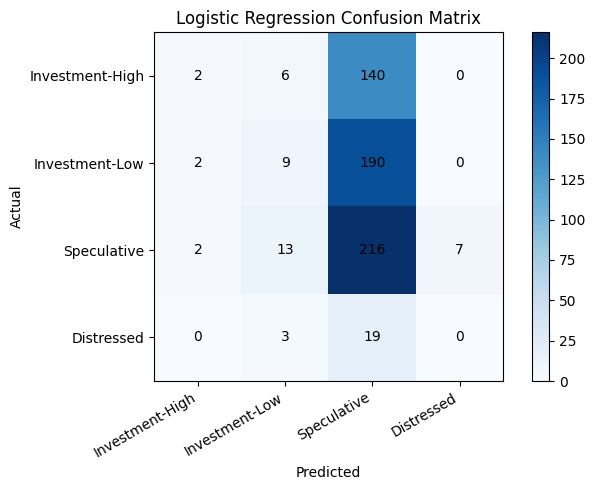

In [11]:
# Step 7: Show the confusion matrix.
cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Logistic Regression Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(
            column_index,
            row_index,
            cm[row_index, column_index],
            ha="center",
            va="center",
            color="black",
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


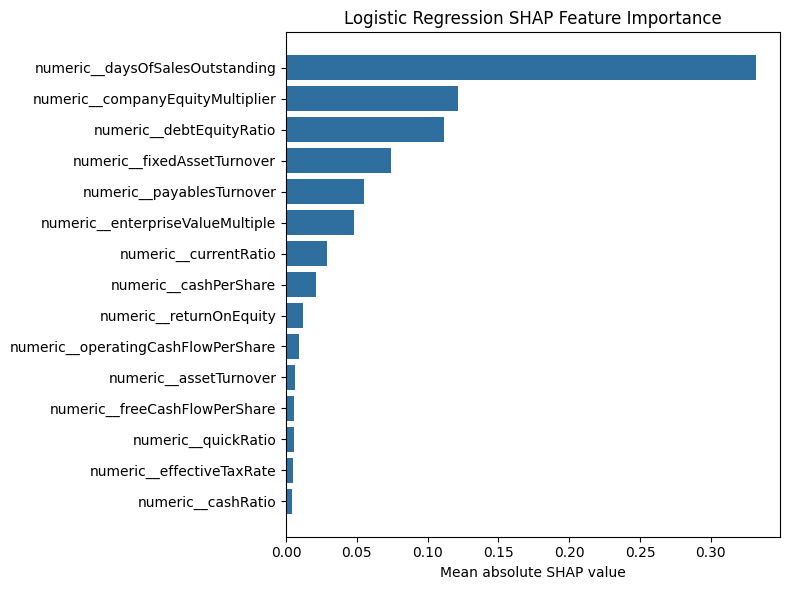

In [12]:
# Step 8: Show SHAP feature importance.
preprocessor = pipeline.named_steps["preprocessor"]
trained_model = pipeline.named_steps["model"]
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
sample_size = min(100, X_test_transformed.shape[0])
shap_sample = X_test_transformed[:sample_size]

if hasattr(shap_sample, "toarray"):
    shap_sample = shap_sample.toarray()

if trained_model.__class__.__name__ == "LogisticRegression":
    shap_explainer = shap.LinearExplainer(trained_model, shap_sample, feature_names=feature_names)
else:
    shap_explainer = shap.TreeExplainer(trained_model, feature_names=feature_names)

shap_values = shap_explainer(shap_sample)
shap_array = shap_values.values
if shap_array.ndim == 3:
    mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 2))
else:
    mean_abs_shap = np.mean(np.abs(shap_array), axis=0)

top_count = min(15, len(feature_names))
top_indices = np.argsort(mean_abs_shap)[-top_count:]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(np.array(feature_names)[top_indices], mean_abs_shap[top_indices], color="#2f6f9f")
ax.set_xlabel("Mean absolute SHAP value")
ax.set_title("Logistic Regression SHAP Feature Importance")
plt.tight_layout()
plt.show()
